# ***SALES PERFORMANCE DASHBOARD WITH  ANALYSIS AND PREDICTION***

# *Project Overview*

### *A Sales Performance Dashboard provides a comprehensive overview of business performance by analyzing key metrics such as sales revenue, profit, order quantity, customer segments, product categories, regions, shipping modes, and discounts. It helps identify sales trends, compare performance across different business dimensions, analyze the impact of discounts on profitability, and generate meaningful business insights. The project also includes predictive modeling using* **Linear Regression, KNN Regressor, and Support Vector Regression (SVR)** *to predict sales-related outcomes and support data-driven decision-making for improving overall business performance.*

# *Product Categories*

The retail business offers products across three major categories:

**Furniture**

- Chairs
- Tables
- Bookcases
- Furnishings


**Office Supplies**

- Binders
- Paper
- Storage
- Labels
- Envelopes
- Art
- Fasteners
- Appliances


**Technology**

- Phones
- Accessories
- Copiers
- Machines

# *Key Columns*:

- **Order Date**: The date when the order was placed.
- **Ship Date**: The date when the order was shipped.
- **Ship Mode**: The shipping mode used for the order.
- **Customer ID**: Unique identifier for each customer.
- **Customer Name**: Name of the customer.
- **Segment**: The segment to which the customer belongs (e.g., Consumer, Corporate, Home Office).
- **Region**: The geographical region of the order.
- **Category**: The category of the product ordered (e.g., Furniture, Office Supplies, Technology).
- **Sub-Category**: The sub-category of the product ordered.
- **Sales**: The sales amount.
- **Quantity**: The quantity of products ordered.
- **Discount**: The discount applied to the order.
- **Profit**: The profit earned from the order.


#*Visualization Libraries*


To perform this analysis and create visualizations, we will use the following Python libraries:

- **Pandas**: For data manipulation and analysis.
- **Matplotlib**: A plotting library for creating static, interactive, and animated visualizations in Python.
- **Seaborn**: A data visualization library based on Matplotlib that provides a high-level interface for drawing attractive and informative statistical graphics.
- **Numpy**:A Python library used for numerical computation,mathematical operations,and working effeciently with arrays and matrices.
- **Sklearn.linear_model**:A machine learning library used to build predictive models.The Linear Regression model is used to predict future values by identifying the relationship between input data and the target variable.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Loading the Sales Performance dataset
df = pd.read_csv(r'/content/drive/MyDrive/sales performance dashboard/Sample - Superstore.csv (1)/Sample - Superstore.csv', encoding='latin1')

In [ ]:
# Displaying the first five rows of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Summary statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
#check for missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#check data type
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [ ]:
# Group data by region and sum sales
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

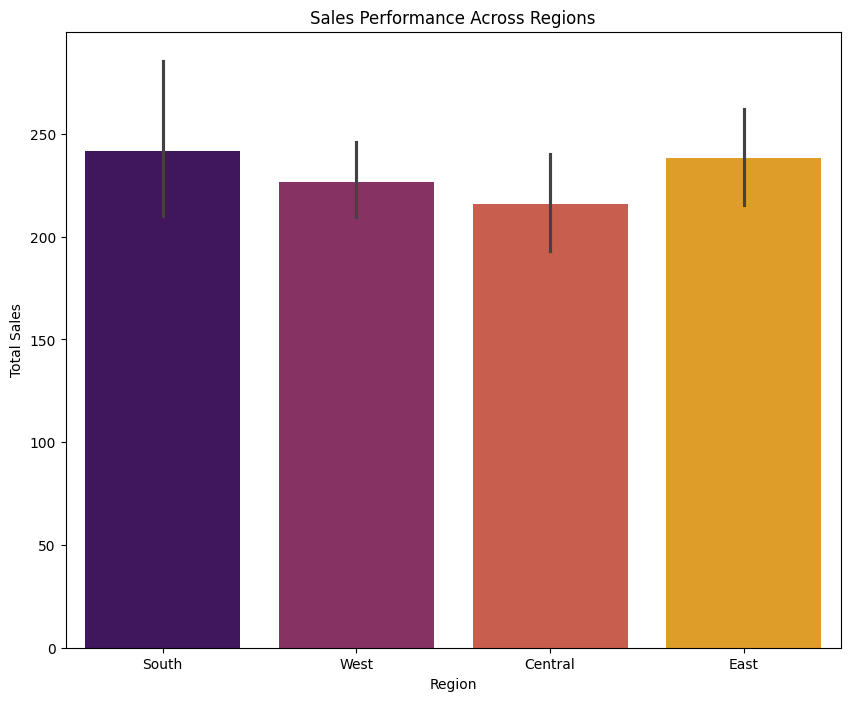

In [ ]:
#plot sales by region
plt.figure(figsize=(10,8))
sns.barplot(x='Region', y='Sales',data=df , palette='inferno')
plt.title('Sales Performance Across Regions')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

**Analysis:**


The bar chart compares total sales across different regions. The south region recorded the highest sales, indicating strong customer demand and market performance. The central region generated the lowest sales, suggesting an opportunity for improved marketing strategies and customer engagement. The variation in sales across regions highlights the importance of regional performance analysis for business decision-making.

In [ ]:
# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create 'YearMonth' column
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

# Group data by 'YearMonth' and sum 'Sales'
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()

# Ensure 'Sales' is numeric
monthly_sales['Sales'] = pd.to_numeric(monthly_sales['Sales'], errors='coerce')

# Drop any rows where 'Sales' could not be converted to numeric
monthly_sales.dropna(subset=['Sales'], inplace=True)

# Convert 'Sales' to float
monthly_sales['Sales'] = monthly_sales['Sales'].astype(float)

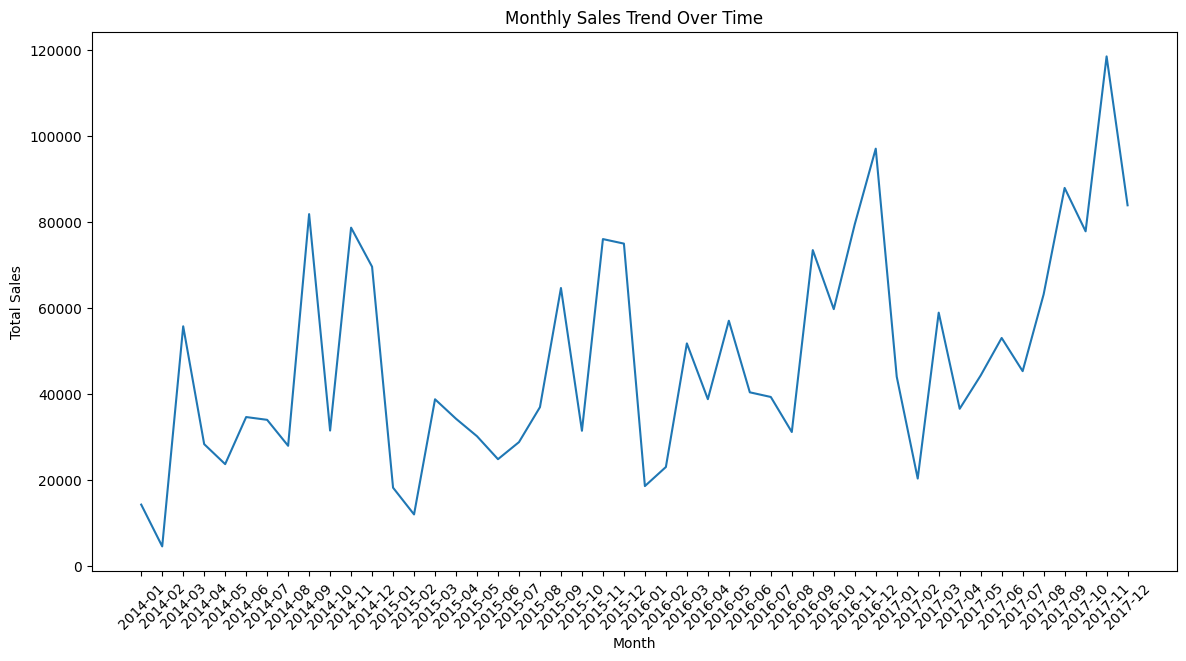

In [ ]:
# Plot sales trend over time
plt.figure(figsize=(14, 7))
sns.lineplot(x='YearMonth', y='Sales', data=monthly_sales)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

**Analysis:**

The monthly sales trend shows regular fluctuation with several peaks and dips.While sales remain relatively consistent overall,certain months generate much higher sales than others.By understanding the factors behind these high-performing months,the company can plan better marketing strategies,promotions,and inventory management to achieve more consistent sales throughout the year.

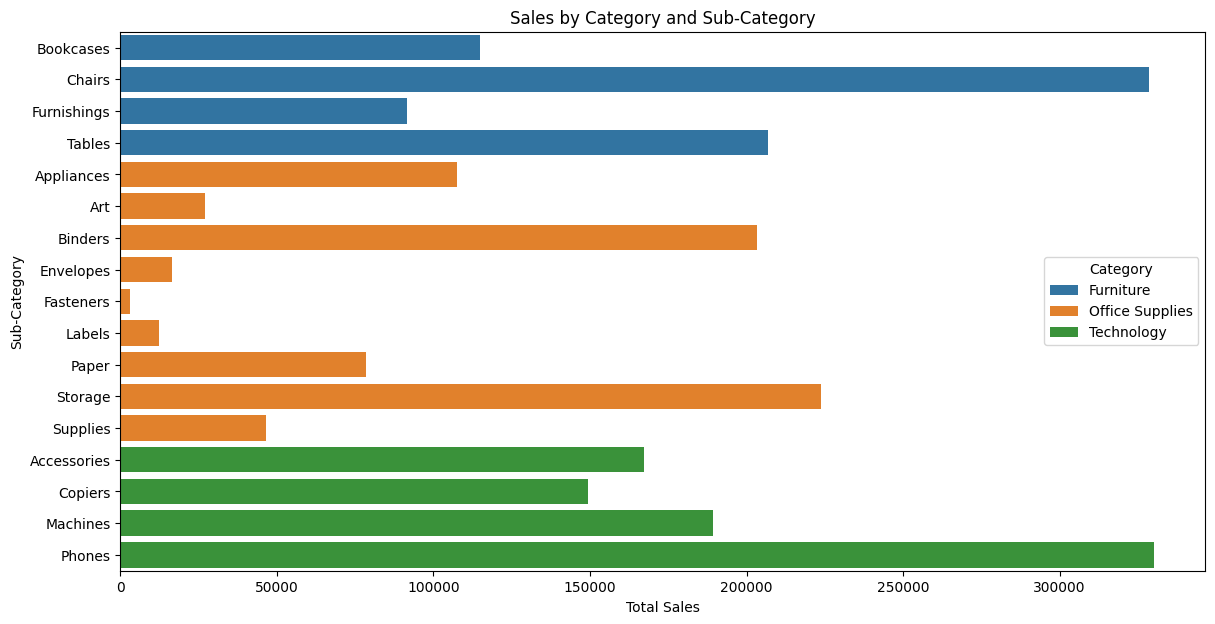

In [ ]:
# Group data by Category and Sub-Category and sum sales
category_sales = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index()

# Plot sales by Category and Sub-Category
plt.figure(figsize=(14, 7))
sns.barplot(x='Sales', y='Sub-Category', hue='Category', data=category_sales)
plt.title('Sales by Category and Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.legend(title='Category')
plt.show()

**Analysis:**

The chart shows that Technology is the strongest-performing category,mainly due to the high sales of Phones.Furniture and Office Supplies also contribute significantly,especially through Chairs,Storage,and Binders.However,some sub-categories such as Fasteners,Labels,Envelopes,and Art have lower sales. The company should continue promoting high-performing products while developing strategies to improve sales of low-performing sub-categories

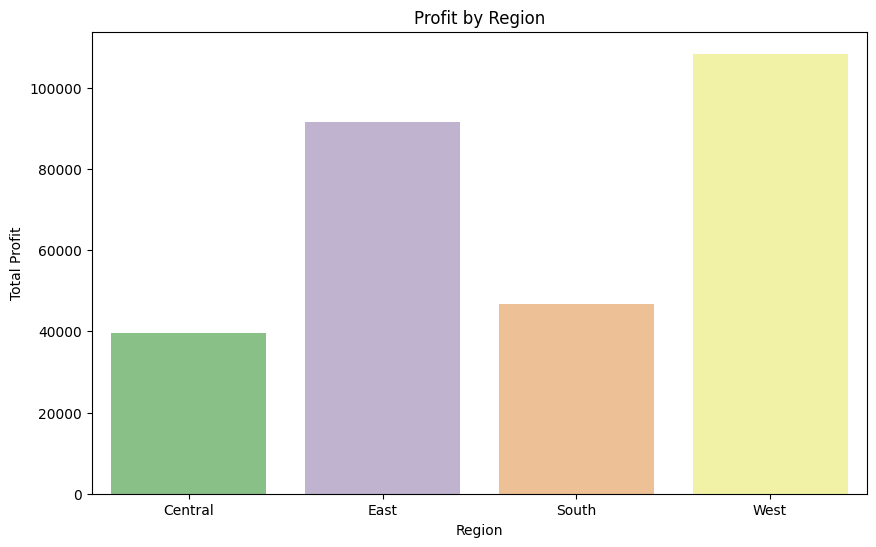

In [ ]:
# Group data by region and sum profit
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

# Plot profit by region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Profit', data=region_profit, palette = "Accent")
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

**Analysis:**

The chart shows that the West region generated the highest profit, indicating strong financial performance and efficient sales operations. Regions with lower profit may require a review of pricing strategies, discount policies, or operational costs to improve overall profitability.

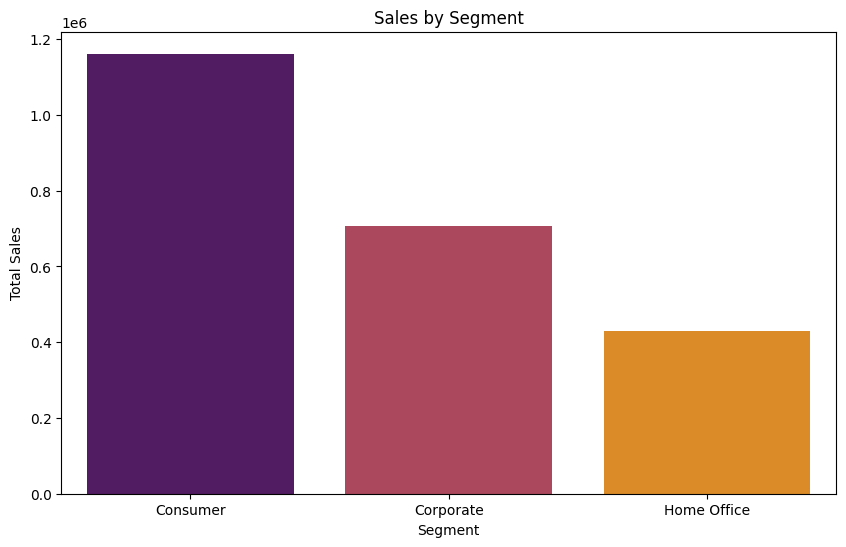

In [ ]:
# Group data by segment and sum sales and profit
segment_sales_profit = df.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

# Plot sales by segment
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Sales', data=segment_sales_profit , palette = 'inferno')
plt.title('Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.show()

**Analysis:**


The Consumer segment generated the highest sales, indicating that individual customers are the primary source of revenue for the business. The Corporate segment also contributes significantly, while the Home Office segment records comparatively lower sales. This suggests that the business should continue focusing on consumer demand while exploring opportunities to increase sales in the Home Office segment.

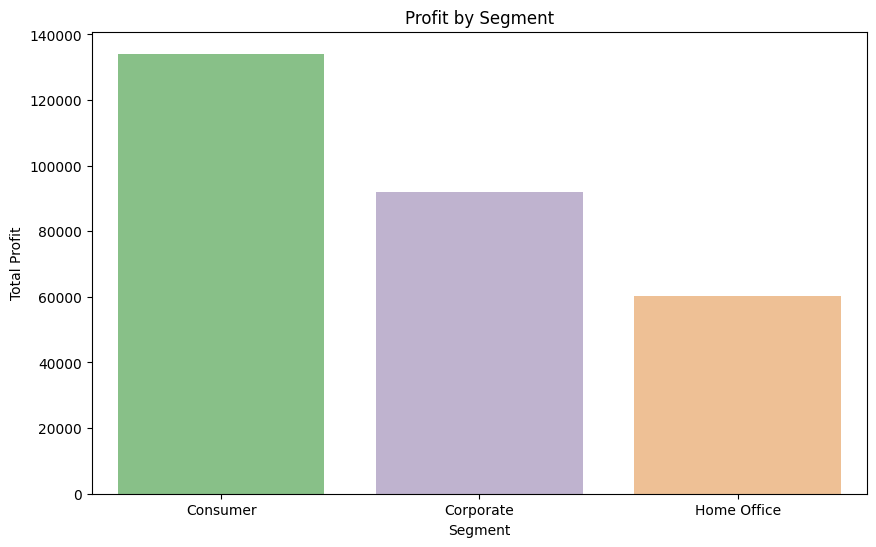

In [ ]:
# Plot profit by segment
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Profit', data=segment_sales_profit, palette = 'Accent')
plt.title('Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.show()

**Analysis:**


The Consumer segment generated the highest profit, making it the most profitable customer group. The Corporate segment also contributed positively to overall profit, while the Home Office segment generated comparatively lower profit. These results indicate that the Consumer segment is a key driver of business profitability, while additional efforts could be made to improve profit from the other customer segments.

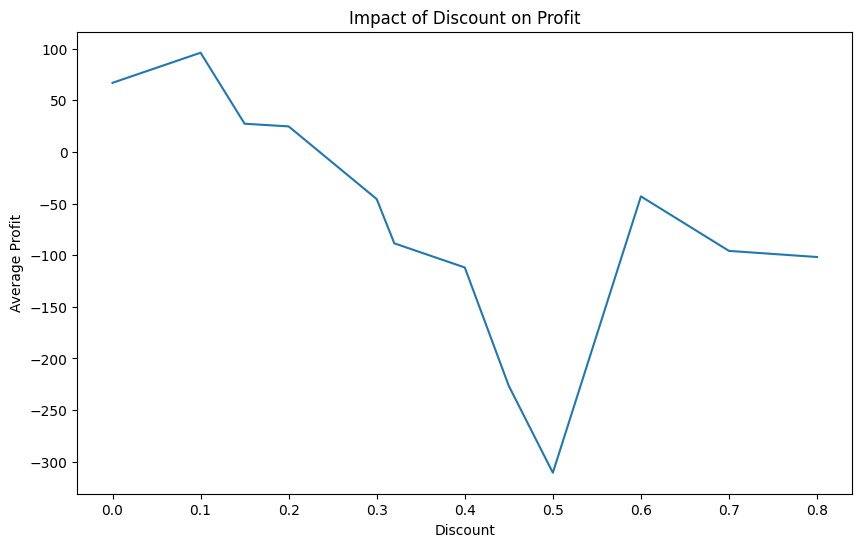

In [ ]:
# Group data by discount and calculate average profit
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()

# Plot profit by discount
plt.figure(figsize=(10, 6))
sns.lineplot(x='Discount', y='Profit', data=discount_profit)
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.show()


**Analysis:**

The graph shows that offering low discounts (0-20%) is more profitable,while discounts (30-80%) results in losses. Therefore,the company should avoid giving excessive discount and instead focus on moderate or low discounts to maximize profit

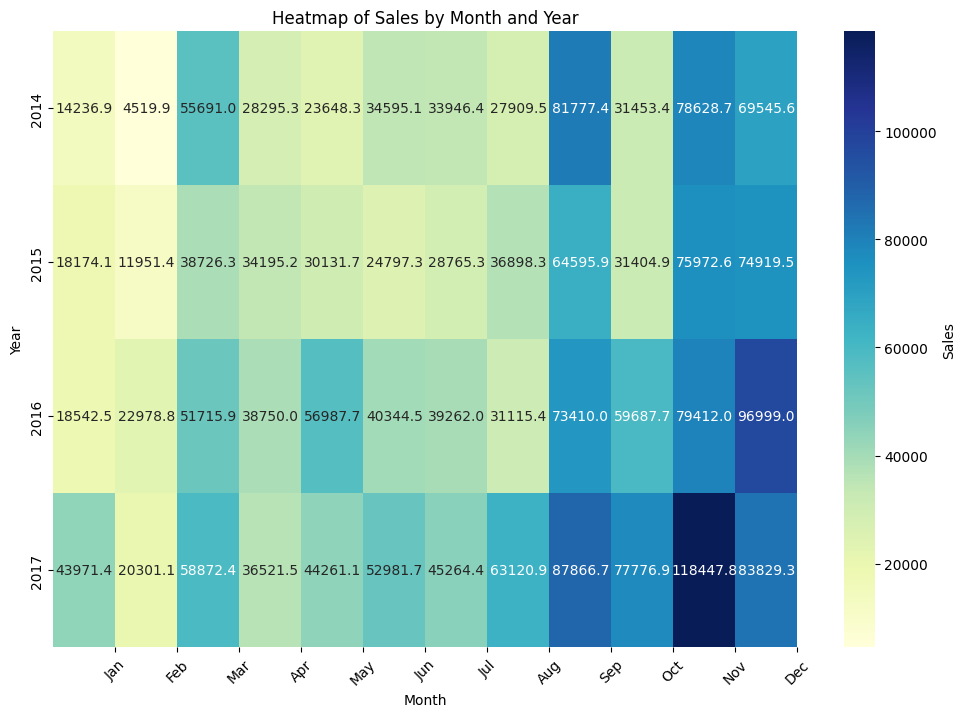

In [ ]:
import calendar

# Extract year and month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Group data by year and month and sum sales
year_month_sales = df.groupby(['Year', 'Month'])['Sales'].sum().unstack()

# Plot heatmap of sales by month and year
plt.figure(figsize=(12, 8))
sns.heatmap(year_month_sales, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Sales'})
plt.title('Heatmap of Sales by Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=range(1, 13), labels=[calendar.month_abbr[i] for i in range(1, 13)], rotation=45)
plt.show()


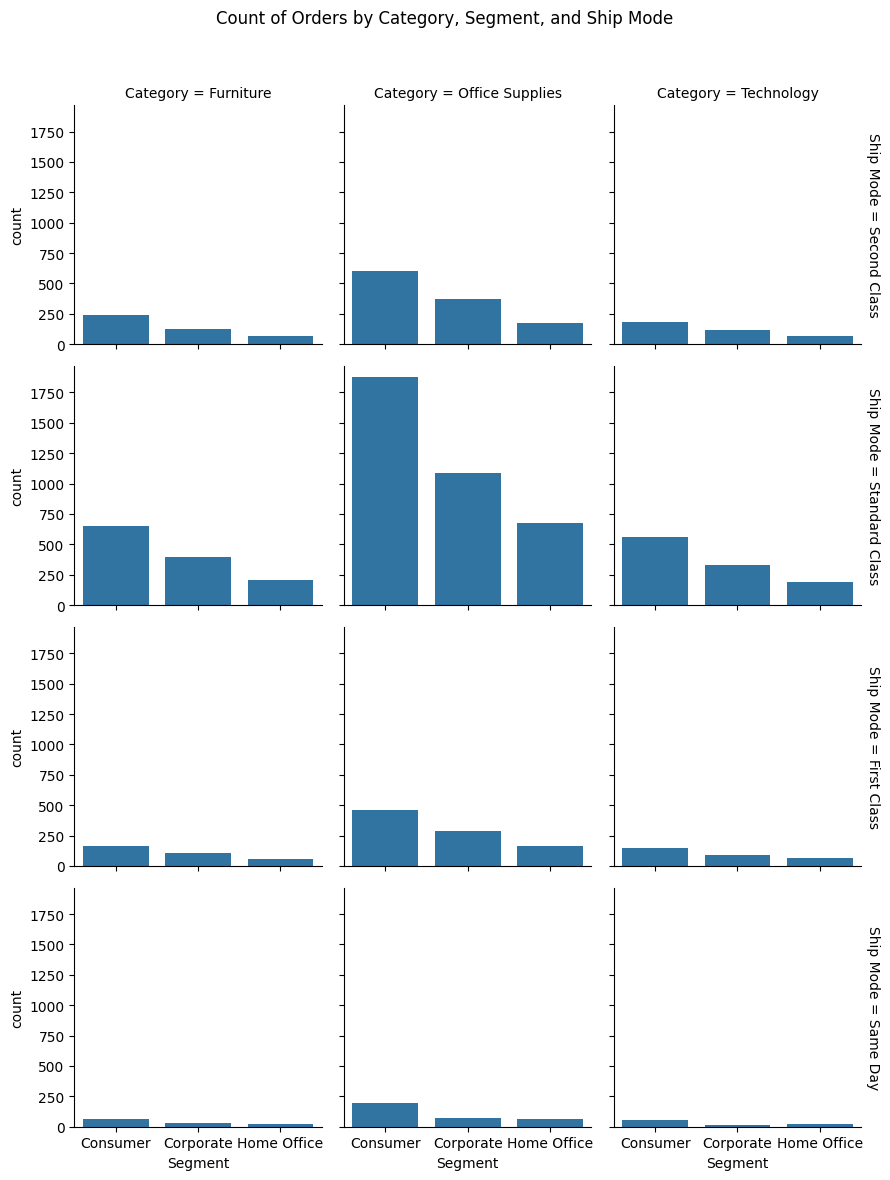

In [ ]:
# Create a FacetGrid for Category and Ship Mode
g = sns.FacetGrid(df, col="Category", row="Ship Mode", margin_titles=True)
g.map(sns.countplot, "Segment", order=df['Segment'].value_counts().index)

# Add titles
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Count of Orders by Category, Segment, and Ship Mode')

# Show the plot
plt.show()


# **Key Findings**

- *Sales performance varies across different regions, with some regions contributing significantly more revenue than others*.
- *Technology products generate the highest sales and profit, while some categories produce lower profit despite strong sales*.
- *Consumer customers contribute the largest share of total sales, followed by Corporate and Home Office customers*.
- *Higher discount rates are associated with lower profit, indicating that excessive discounting can negatively impact profitability*.
- *Standard Class is the most frequently used shipping mode, demonstrating customer preference for cost-effective delivery*.
- *A small group of customers accounts for a substantial portion of total sales, highlighting the importance of customer retention*.

## *After analyzing the sales data,the next step is prediction.The main goal of the prediction is to estimate future sales based on historical sales trends and patterns.*

# *Data Preprocessing*

### *In this step, the dataset is prepared for analysis and machine learning by checking for missing values, duplicates, incorrect data types, and unnecessary columns. The data is cleaned and transformed to ensure consistency and quality before performing exploratory data analysis and predictive modeling*.

In [ ]:
# Checking for missing values in each column
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Removing the unnecessary Row ID column
df.drop('Row ID',axis=1,inplace=True, errors='ignore')

In [ ]:
df.drop('Customer ID',axis=1,inplace=True, errors='ignore')

In [ ]:
# Encoding the Region column into numerical values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Region"] = le.fit_transform(df["Region"])

# *Model Creation*

### *In this step, a Linear Regression model is created to predict the target sales-related variable using the selected features. The model learns the relationship between the input variables and the target variable and is then used to generate predictions for performance evaluation*.


In [ ]:
# Selecting input features and target variable
X=df[['Region','Sales']]
y=df.Profit

In [ ]:
# Splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [ ]:
# Displaying the training target variable
y_train

,Profit
5601,-3.5622
9122,3.5010
3560,0.6192
5316,1.3284
7553,12.4416
...,...
456,-24.2940
6017,9.3312
709,15.7680
8366,7.3872


In [ ]:
#Creating model
#object creation
#training of linear regression
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
y_predict=LR.predict(X_test)

In [ ]:
#Actual values
y_test

,Profit
7501,52.9173
7873,3.8520
4885,52.5320
445,10.5840
9491,3.1008
...,...
4977,2.3408
6782,3.0144
9090,104.5680
9162,176.8026


In [ ]:
#Values predicted by model
y_predict

array([72.22480367, -1.76685276,  4.31821636, ..., 49.09409132,
       94.97167818, 50.10987921])

In [ ]:
#Model Evalution
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2score=r2_score(y_test,y_predict)

In [ ]:
# Calculating the R² score
r2score

0.3496696350007338

In [ ]:
#Calculation of adjusted r2 score
adjusted_r2 = 1-(1-0.90)*(40-3)/(40-3-1)
adjusted_r2

0.8972222222222223

In [ ]:
#Calculation of MAE
print(mean_absolute_error(y_test,y_predict))

52.04815806967147


In [ ]:
#Calculation of MSE
print(mean_squared_error(y_test,y_predict))

41366.3277463083


# *Logistic Regression*

### *Logistic Regression is a supervised machine learning algorithm used mainly for classification problems. It predicts the probability of an input belonging to a particular class and assigns it to a category based on a probability threshold. In the Sales Performance project, it can be used to classify outcomes such as profitable vs. non-profitable sales*.

In [ ]:
# Scaling numerical features using Min-Max Scaler
from sklearn.preprocessing import MinMaxScaler
st=MinMaxScaler()
dl=['Customer Name','Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Country', 'City', 'State', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'YearMonth']
df1=st.fit_transform(df.drop(dl,axis=1))

In [ ]:
# Selecting categorical columns for conversion and analysis
con_df=df[['Customer Name','Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Country', 'City', 'State', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'YearMonth']]
con_df

,Customer Name,Order ID,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Product ID,Category,Sub-Category,Product Name,YearMonth
0,Claire Gute,CA-2016-152156,2016-11-08,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,2016-11
1,Claire Gute,CA-2016-152156,2016-11-08,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",2016-11
2,Darrin Van Huff,CA-2016-138688,2016-06-12,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,2016-06
3,Sean O'Donnell,US-2015-108966,2015-10-11,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,2015-10
4,Sean O'Donnell,US-2015-108966,2015-10-11,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,2015-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Tom Boeckenhauer,CA-2014-110422,2014-01-21,1/23/2014,Second Class,Consumer,United States,Miami,Florida,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,2014-01
9990,Dave Brooks,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,2017-02
9991,Dave Brooks,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,2017-02
9992,Dave Brooks,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,Consumer,United States,Costa Mesa,California,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",2017-02


In [ ]:
# Converting the scaled data into a DataFrame
type(df1)
df2=pd.DataFrame(df1,columns=['Postal Code', 'Region', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month'])
df2

,Postal Code,Region,Sales,Quantity,Discount,Profit,Year,Month
0,0.421123,0.666667,0.011552,0.076923,0.0000,0.442794,0.666667,0.909091
1,0.421123,0.666667,0.032313,0.153846,0.0000,0.454639,0.666667,0.909091
2,0.905710,1.000000,0.000626,0.076923,0.0000,0.440458,0.666667,0.454545
3,0.328421,0.666667,0.042280,0.307692,0.5625,0.414464,0.333333,0.818182
4,0.328421,0.666667,0.000968,0.076923,0.2500,0.440168,0.333333,0.818182
...,...,...,...,...,...,...,...,...
9989,0.327088,0.666667,0.001096,0.153846,0.2500,0.440273,0.000000,0.000000
9990,0.932079,1.000000,0.004043,0.076923,0.0000,0.441042,1.000000,0.090909
9991,0.932079,1.000000,0.011403,0.076923,0.2500,0.441293,1.000000,0.090909
9992,0.932079,1.000000,0.001288,0.230769,0.0000,0.440888,1.000000,0.090909


In [ ]:
# Combining the processed numerical and categorical data
final_df=pd.concat([df2,con_df],axis=1)

In [ ]:
# Displaying the final processed dataset
final_df

,Postal Code,Region,Sales,Quantity,Discount,Profit,Year,Month,Customer Name,Order ID,...,Ship Mode,Segment,Country,City,State,Product ID,Category,Sub-Category,Product Name,YearMonth
0,0.421123,0.666667,0.011552,0.076923,0.0000,0.442794,0.666667,0.909091,Claire Gute,CA-2016-152156,...,Second Class,Consumer,United States,Henderson,Kentucky,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,2016-11
1,0.421123,0.666667,0.032313,0.153846,0.0000,0.454639,0.666667,0.909091,Claire Gute,CA-2016-152156,...,Second Class,Consumer,United States,Henderson,Kentucky,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",2016-11
2,0.905710,1.000000,0.000626,0.076923,0.0000,0.440458,0.666667,0.454545,Darrin Van Huff,CA-2016-138688,...,Second Class,Corporate,United States,Los Angeles,California,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,2016-06
3,0.328421,0.666667,0.042280,0.307692,0.5625,0.414464,0.333333,0.818182,Sean O'Donnell,US-2015-108966,...,Standard Class,Consumer,United States,Fort Lauderdale,Florida,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,2015-10
4,0.328421,0.666667,0.000968,0.076923,0.2500,0.440168,0.333333,0.818182,Sean O'Donnell,US-2015-108966,...,Standard Class,Consumer,United States,Fort Lauderdale,Florida,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,2015-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,0.327088,0.666667,0.001096,0.153846,0.2500,0.440273,0.000000,0.000000,Tom Boeckenhauer,CA-2014-110422,...,Second Class,Consumer,United States,Miami,Florida,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,2014-01
9990,0.932079,1.000000,0.004043,0.076923,0.0000,0.441042,1.000000,0.090909,Dave Brooks,CA-2017-121258,...,Standard Class,Consumer,United States,Costa Mesa,California,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,2017-02
9991,0.932079,1.000000,0.011403,0.076923,0.2500,0.441293,1.000000,0.090909,Dave Brooks,CA-2017-121258,...,Standard Class,Consumer,United States,Costa Mesa,California,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,2017-02
9992,0.932079,1.000000,0.001288,0.230769,0.0000,0.440888,1.000000,0.090909,Dave Brooks,CA-2017-121258,...,Standard Class,Consumer,United States,Costa Mesa,California,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",2017-02


In [ ]:
# Selecting input features and creating the binary target variable
X=df2.iloc[:,:-1]
y=(df['Profit'] > 0).astype(int)

In [ ]:
# Displaying the target variable
y

,Profit
0,1
1,1
2,1
3,0
4,1
...,...
9989,1
9990,1
9991,1
9992,1


In [ ]:
# Splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=45)

In [ ]:
# Displaying the test target variable
y_test

,Profit
3573,1
8906,1
3142,1
1876,1
6399,1
...,...
9110,1
8195,1
4054,1
2336,1


In [ ]:
# Training the Logistic Regression classification model
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train, (y_train > 0).astype(int))

LogisticRegression()

In [ ]:
# Predicting the classes for the test data
y_pred=clf.predict(X_test)

In [ ]:
# Displaying the predicted class values
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
# Calculating class prediction probabilities
y_pred_prob=clf.predict_proba(X_test)

In [ ]:
# Viewing Prediction Probabilities
y_pred_prob

array([[0.00807292, 0.99192708],
       [0.00610473, 0.99389527],
       [0.17792405, 0.82207595],
       ...,
       [0.17651905, 0.82348095],
       [0.00667049, 0.99332951],
       [0.00730298, 0.99269702]])

In [ ]:
# Importing classification evaluation metrics
from sklearn.metrics import(confusion_matrix,accuracy_score,recall_score,precision_score,classification_report,f1_score)

In [ ]:
# Generating the confusion matrix and printing the classification results
cd=confusion_matrix((y_test > 0).astype(int),y_pred)
print(cd)

[[ 250  116]
 [   8 1625]]


In [ ]:
# Calculating recall score
recall=recall_score((y_test > 0).astype(int),y_pred)
recall

0.9951010410287814

In [ ]:
# Calculating precision score
precision=precision_score((y_test > 0).astype(int),y_pred)
precision

0.9333716255025847

In [ ]:
# Calculating F1 score
f1score=f1_score((y_test > 0).astype(int),y_pred)
f1score

0.9632483698873741

In [ ]:
# Generating the classification report
cr=classification_report((y_test > 0).astype(int),y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.97      0.68      0.80       366
           1       0.93      1.00      0.96      1633

    accuracy                           0.94      1999
   macro avg       0.95      0.84      0.88      1999
weighted avg       0.94      0.94      0.93      1999



# *KNN Model*

### *K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression. It predicts the output based on the values of the nearest data points. In this project, KNN is used to classify sales records based on their similarity to neighboring observations*.


In [ ]:
# import all required libraries

import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor # For regression task
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

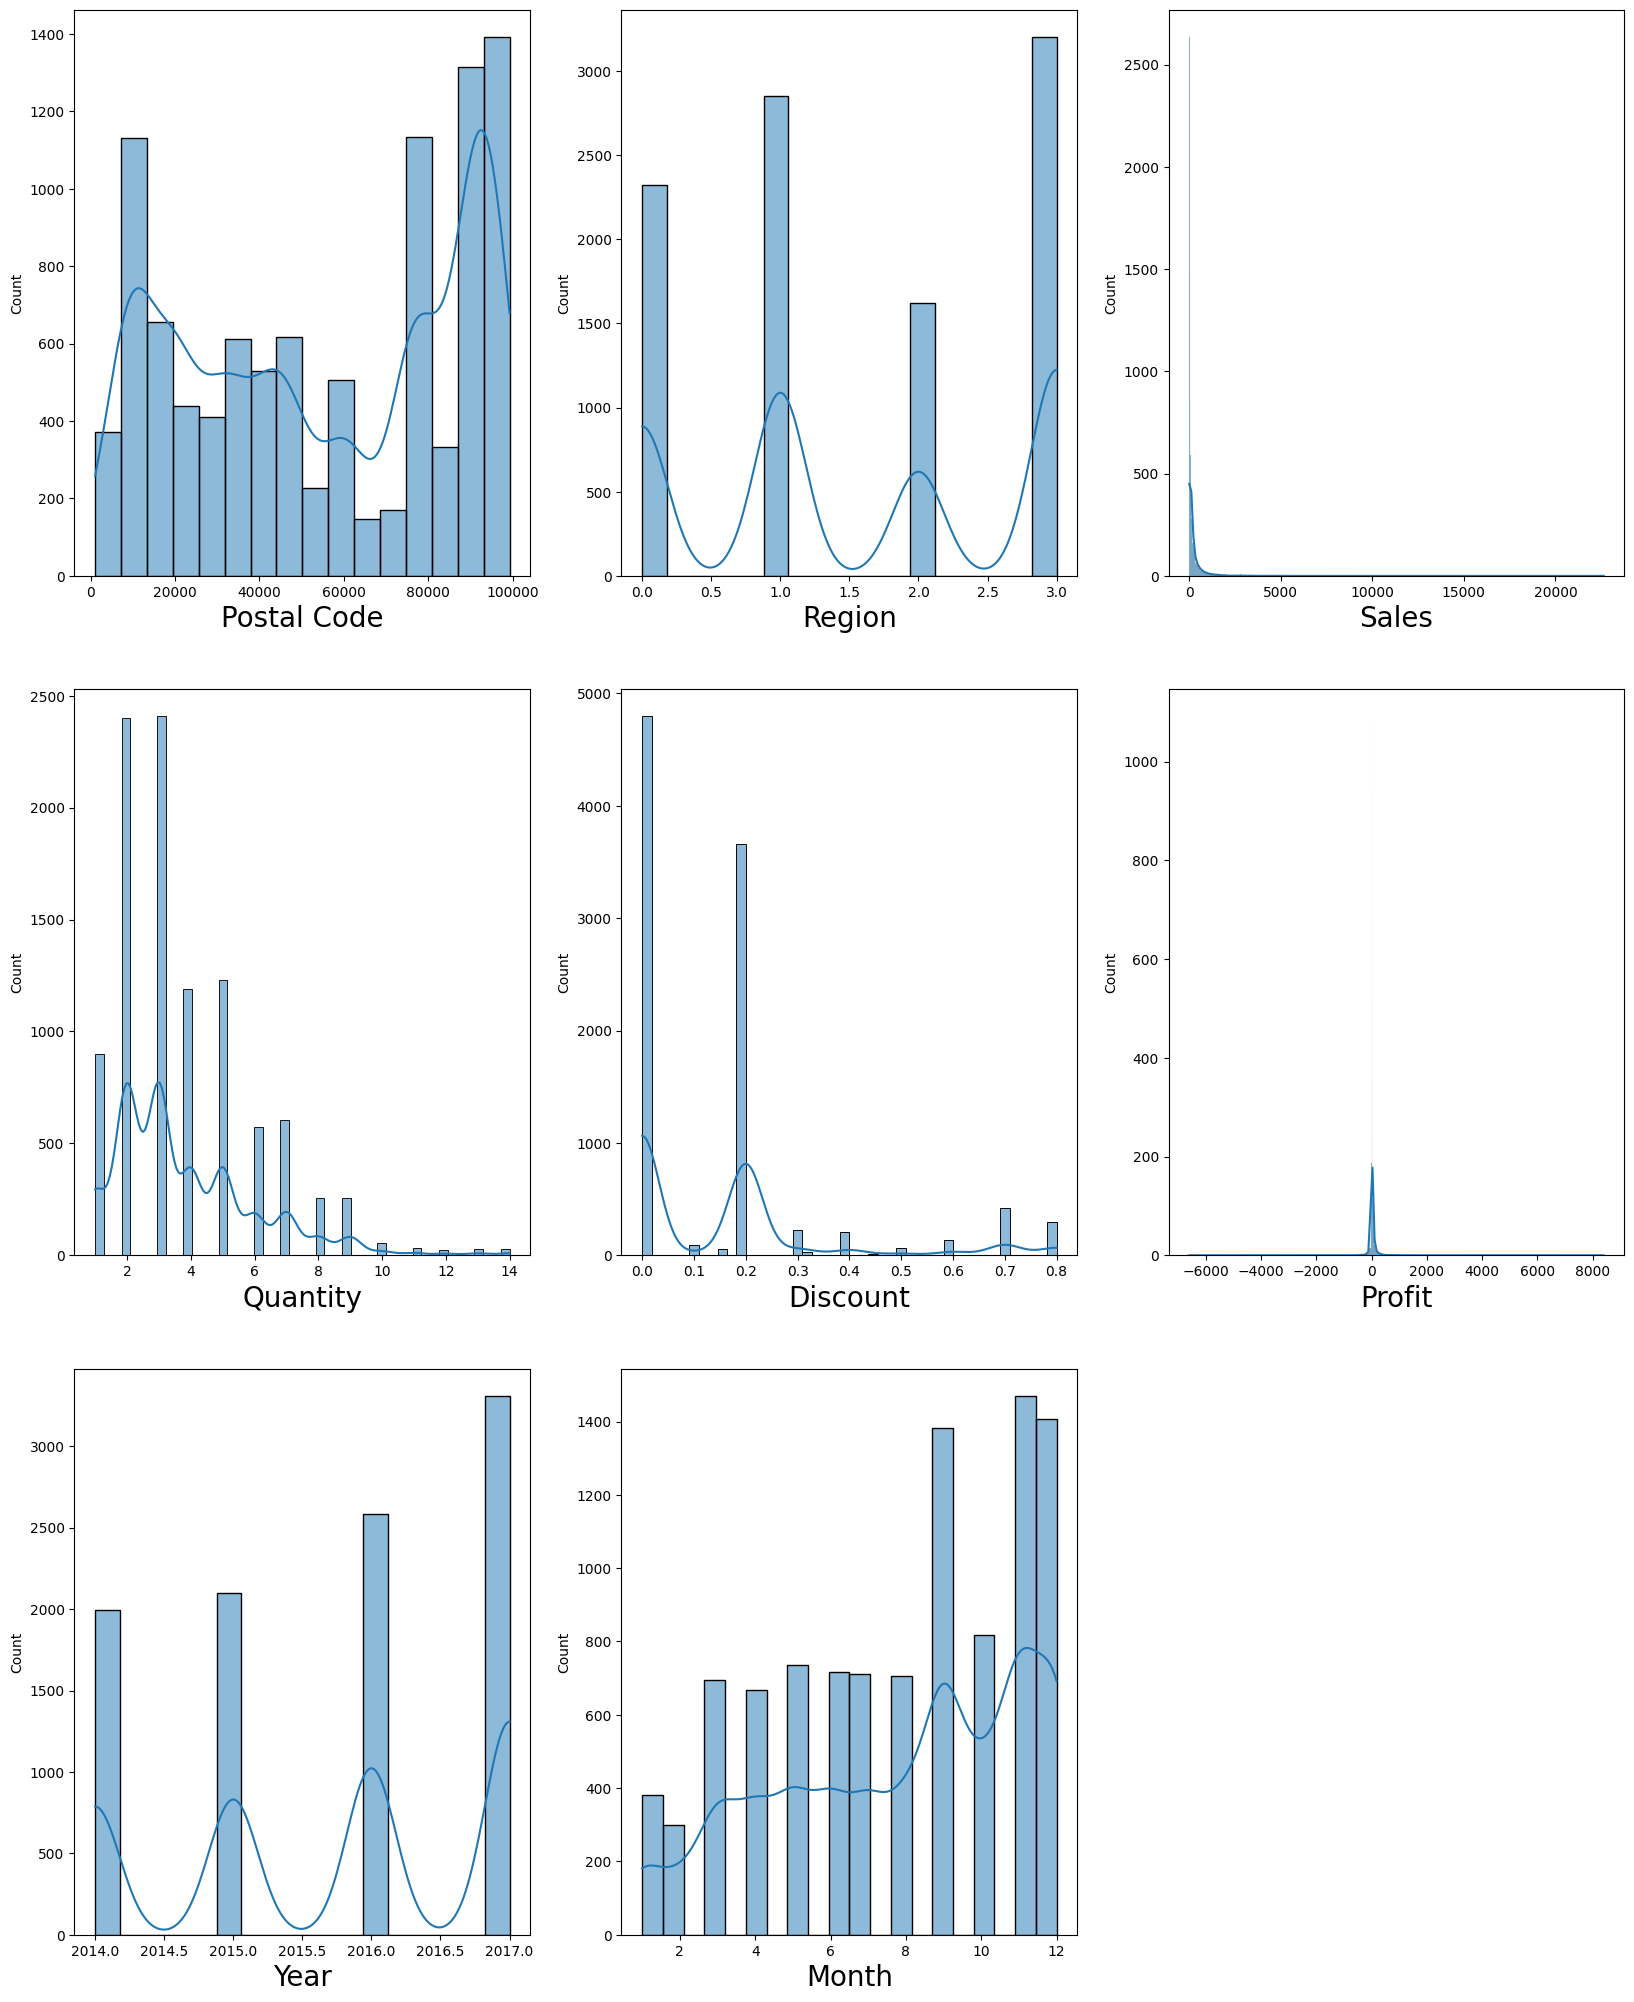

In [ ]:
# let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

# Select only numerical columns for distribution plots
numerical_cols = df.select_dtypes(include=np.number).columns

for column in numerical_cols:
    if plotnumber<=9 :     # limit to 9 plots to fit in a 3x3 grid
        ax = plt.subplot(3,3,plotnumber)
        sns.histplot(df[column], kde=True) # Using histplot with kde as distplot is deprecated
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Sales',fontsize=20)
    plotnumber+=1
plt.show()

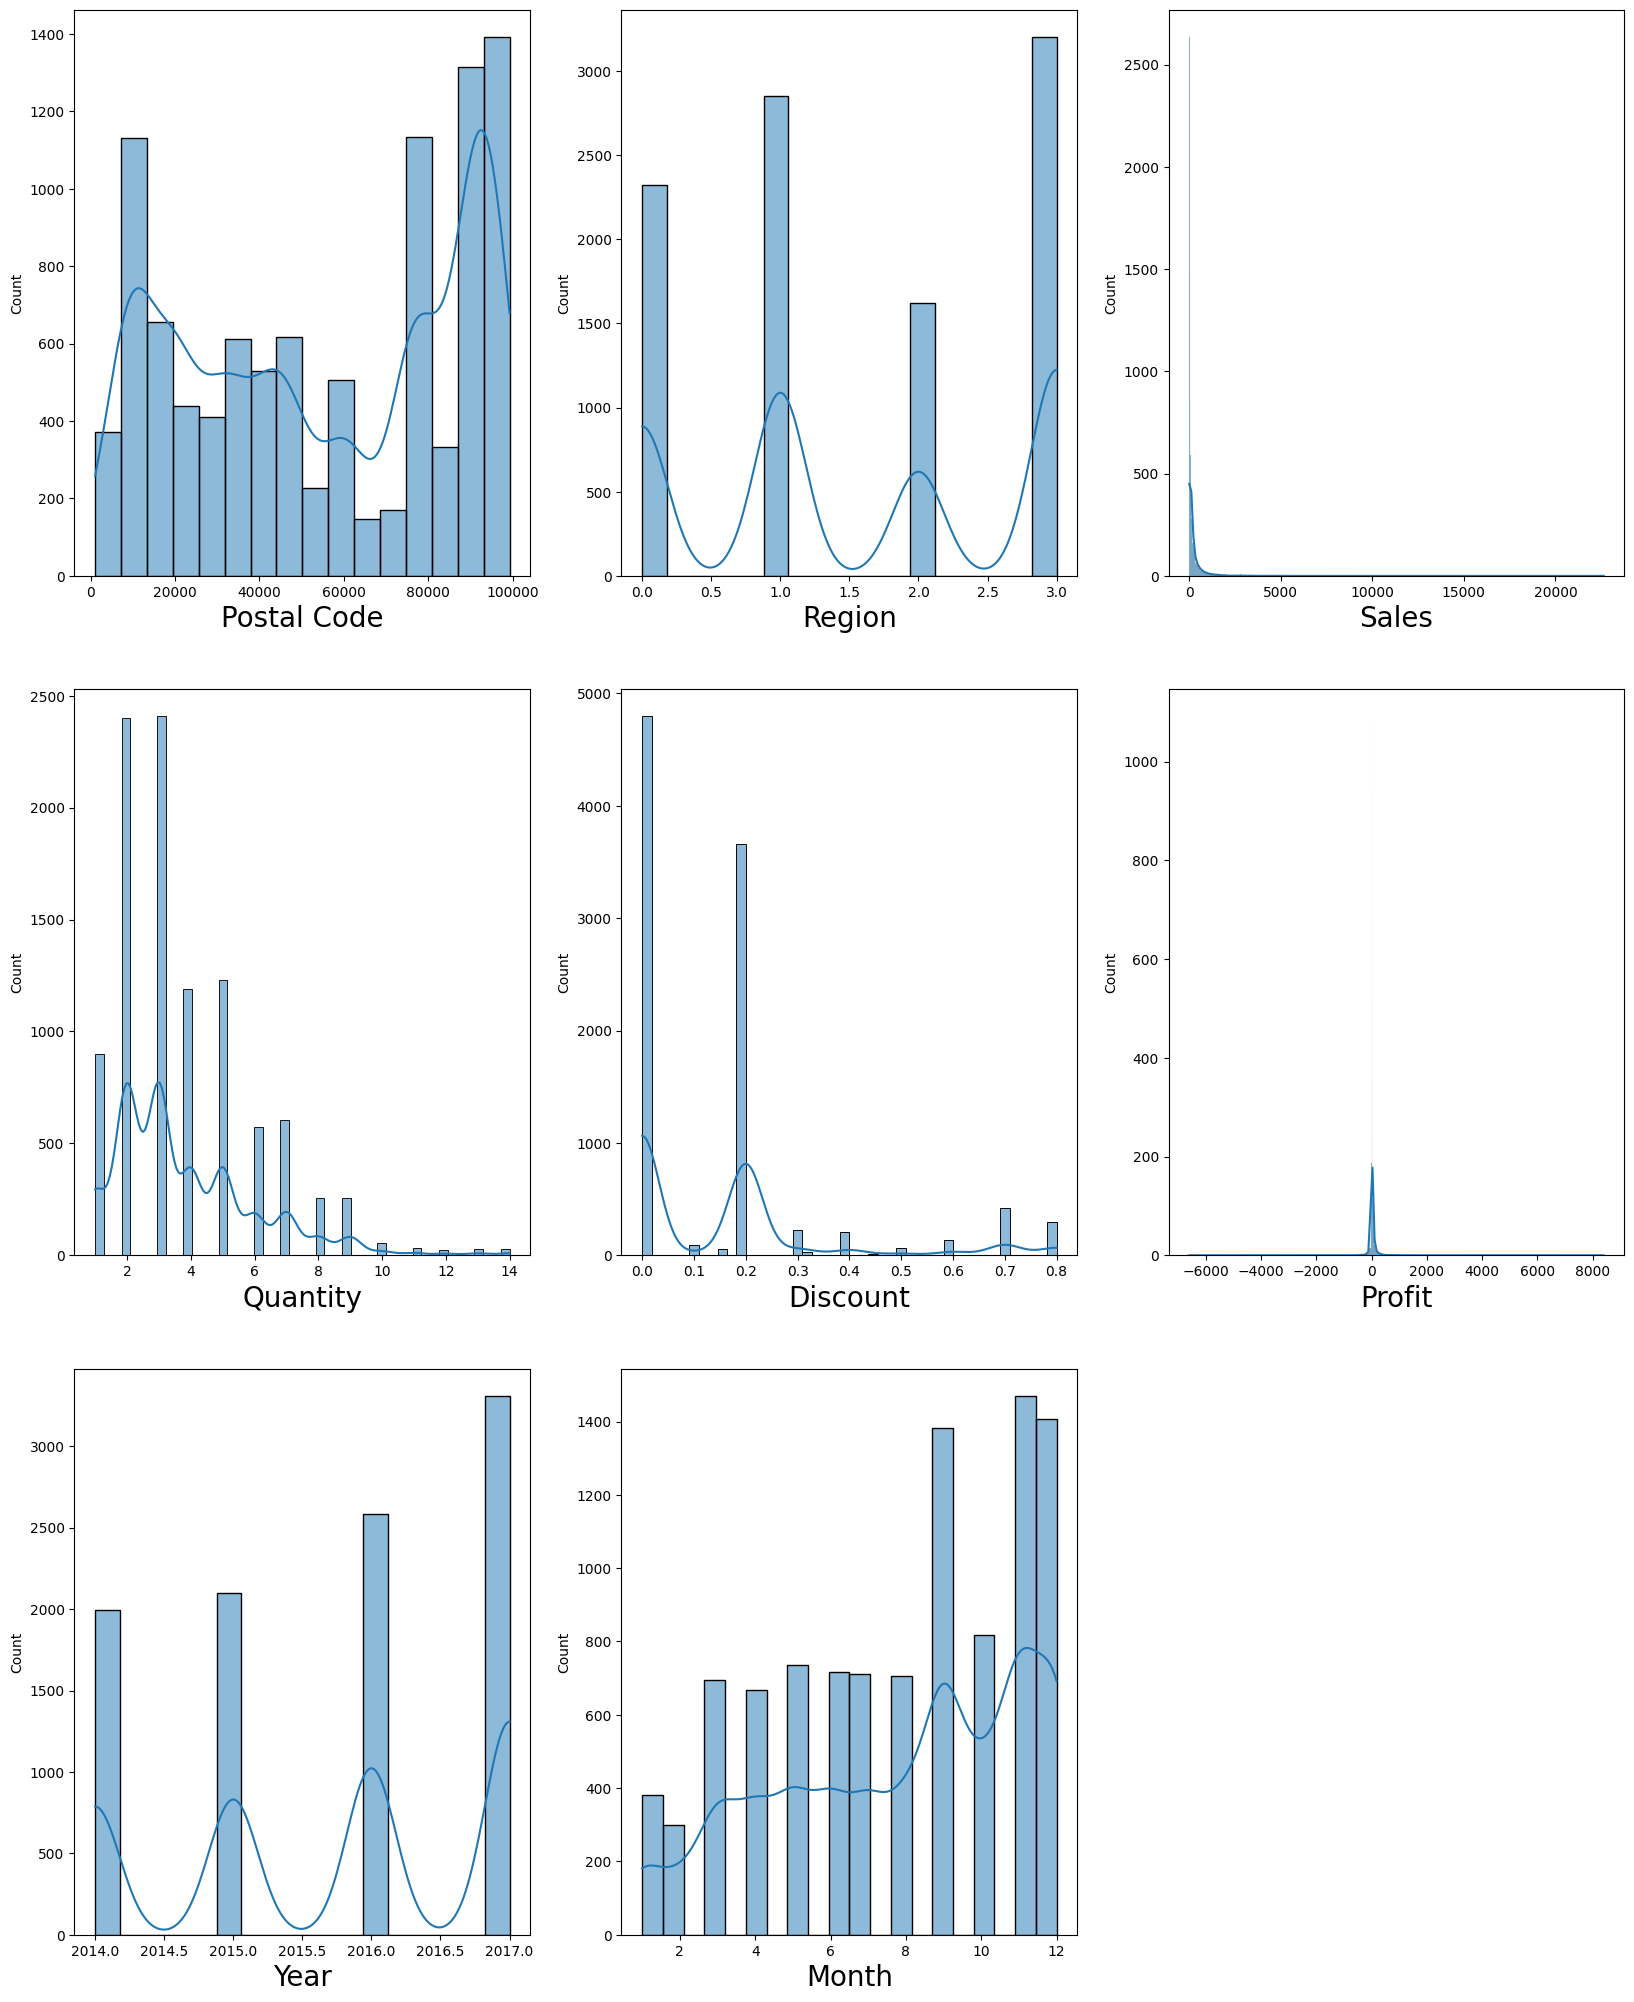

In [ ]:
# let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

# Select only numerical columns for distribution plots
numerical_cols = df.select_dtypes(include=np.number).columns

for column in numerical_cols:
    if plotnumber<=9 :     # limit to 9 plots to fit in a 3x3 grid
        ax = plt.subplot(3,3,plotnumber)
        sns.histplot(df[column], kde=True) # Using histplot with kde as distplot is deprecated
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.show()

# *Model Creation*

### *In this step, the K-Nearest Neighbors (KNN) model is created by selecting the optimal number of neighbors (K) and training the model using the prepared training dataset. The trained model is then used to classify sales records based on their nearest observations*.


In [ ]:
### Split X and Y
X = df.drop(columns = ['Profit']) # Independent variables
y = df['Profit'] # Dependent or target varaible.

In [ ]:
## scaling the data
scalar = StandardScaler()
# Select only numerical columns from X for scaling
X_numeric = X.select_dtypes(include=np.number)
X_scaled = scalar.fit_transform(X_numeric)

In [ ]:
## splitting the training and testing data
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,random_state=42)

In [ ]:
## taking optimal k to determine how many nearest neighbors  to create

# Convert y_train and y_test to binary for regressor
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

# create a list to store the error values for each k
error_rate = []

# Will take some time
for i in range(1,11):
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(X_train, y_train_binary) # Use binary y_train
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test_binary)) # Compare with binary y_test

In [ ]:
# Checking the error rate for different K values
error_rate

[np.float64(0.10124049619847938),
 np.float64(0.15126050420168066),
 np.float64(0.19807923169267708),
 np.float64(0.23729491796718688),
 np.float64(0.266906762705082),
 np.float64(0.2961184473789516),
 np.float64(0.33013205282112845),
 np.float64(0.3477390956382553),
 np.float64(0.37334933973589435),
 np.float64(0.39215686274509803)]

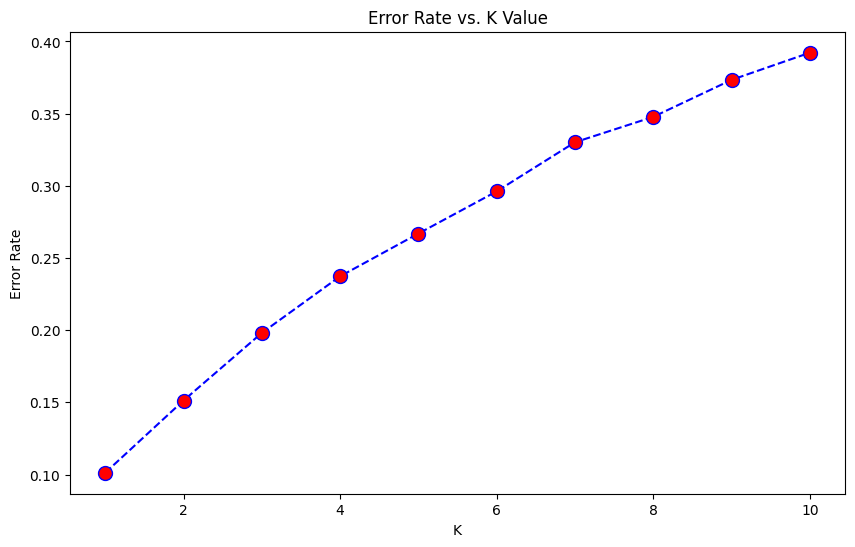

In [ ]:
# Lets plot the k-value and error rate

plt.figure(figsize=(10,6))
plt.plot(range(1,11),error_rate,color='blue', linestyle='dashed',
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [ ]:
## This is reference code donot run this on current dataset.
## Error calculation for regression task
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

rmse_val = [] #create list to store rmse values for different k
for K in range(1,20):

    model = KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test) #make prediction on test set
    error = np.sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 299.5386425460986
RMSE value for k=  2 is: 283.2931433775693
RMSE value for k=  3 is: 248.2381721602583
RMSE value for k=  4 is: 245.07431438542582
RMSE value for k=  5 is: 243.71825276613197
RMSE value for k=  6 is: 239.98331925065747
RMSE value for k=  7 is: 228.29142404757866
RMSE value for k=  8 is: 226.04451422996178
RMSE value for k=  9 is: 219.3855631865236
RMSE value for k=  10 is: 219.31198621070197
RMSE value for k=  11 is: 207.97438030625784
RMSE value for k=  12 is: 210.30942553625238
RMSE value for k=  13 is: 212.5600033841859
RMSE value for k=  14 is: 211.1670441357244
RMSE value for k=  15 is: 211.91205982326164
RMSE value for k=  16 is: 211.6889909177403
RMSE value for k=  17 is: 209.7660253721372
RMSE value for k=  18 is: 211.57355143572312
RMSE value for k=  19 is: 207.6319522648173


In [ ]:
# let's fit the data into KNN model and see how well it performs:
from sklearn.neighbors import KNeighborsRegressor
knn1 = KNeighborsRegressor(n_neighbors=5)
knn1.fit(X_train,y_train)

KNeighborsRegressor()

In [ ]:
## This is reference code donot run this on current dataset.
## Error calculation for regression task
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

rmse_val = [] #create list to store rmse values for different k
for K in range(1,20):

    model = KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test) #make prediction on test set
    error = np.sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 299.5386425460986
RMSE value for k=  2 is: 283.2931433775693
RMSE value for k=  3 is: 248.2381721602583
RMSE value for k=  4 is: 245.07431438542582
RMSE value for k=  5 is: 243.71825276613197
RMSE value for k=  6 is: 239.98331925065747
RMSE value for k=  7 is: 228.29142404757866
RMSE value for k=  8 is: 226.04451422996178
RMSE value for k=  9 is: 219.3855631865236
RMSE value for k=  10 is: 219.31198621070197
RMSE value for k=  11 is: 207.97438030625784
RMSE value for k=  12 is: 210.30942553625238
RMSE value for k=  13 is: 212.5600033841859
RMSE value for k=  14 is: 211.1670441357244
RMSE value for k=  15 is: 211.91205982326164
RMSE value for k=  16 is: 211.6889909177403
RMSE value for k=  17 is: 209.7660253721372
RMSE value for k=  18 is: 211.57355143572312
RMSE value for k=  19 is: 207.6319522648173


In [ ]:
## This is reference code donot run this on current dataset.
## Error calculation for regression task
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

rmse_val = [] #create list to store rmse values for different k
for K in range(1,20):

    model = KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test) #make prediction on test set
    error = np.sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 299.5386425460986
RMSE value for k=  2 is: 283.2931433775693
RMSE value for k=  3 is: 248.2381721602583
RMSE value for k=  4 is: 245.07431438542582
RMSE value for k=  5 is: 243.71825276613197
RMSE value for k=  6 is: 239.98331925065747
RMSE value for k=  7 is: 228.29142404757866
RMSE value for k=  8 is: 226.04451422996178
RMSE value for k=  9 is: 219.3855631865236
RMSE value for k=  10 is: 219.31198621070197
RMSE value for k=  11 is: 207.97438030625784
RMSE value for k=  12 is: 210.30942553625238
RMSE value for k=  13 is: 212.5600033841859
RMSE value for k=  14 is: 211.1670441357244
RMSE value for k=  15 is: 211.91205982326164
RMSE value for k=  16 is: 211.6889909177403
RMSE value for k=  17 is: 209.7660253721372
RMSE value for k=  18 is: 211.57355143572312
RMSE value for k=  19 is: 207.6319522648173


In [ ]:
# Predict
y_pred = knn1.predict(X_test)

In [ ]:
# Generating the classification report
print(classification_report((y_test > 0).astype(int), (y_pred > 0).astype(int)))

              precision    recall  f1-score   support

           0       0.78      0.69      0.73       459
           1       0.93      0.96      0.94      2040

    accuracy                           0.91      2499
   macro avg       0.86      0.82      0.84      2499
weighted avg       0.90      0.91      0.90      2499



# *SUPPORT VECTOR REGRESSION (SVR)*

### *Support Vector Regression (SVR) is a supervised machine learning algorithm used for predicting continuous numerical values. In this project, SVR is used to analyze the relationship between sales-related features and profit, helping predict profit values based on the selected input features.*


In [ ]:
# Creating and training the SVR model
from sklearn.svm import SVR
svclassifier = SVR()
svclassifier.fit(X_train, y_train)

SVR()

In [ ]:
# Predict output for X_test
y_hat=svclassifier.predict(X_test)

In [ ]:
# Calssification report measures the quality of predictions. True Positives, False Positives, True negatives and False Negatives
# are used to predict the metrics of a classification report

print(classification_report((y_test > 0).astype(int),(y_hat > 0).astype(int)))

              precision    recall  f1-score   support

           0       0.97      0.49      0.65       459
           1       0.90      1.00      0.94      2040

    accuracy                           0.90      2499
   macro avg       0.93      0.75      0.80      2499
weighted avg       0.91      0.90      0.89      2499



# *Key Findings*

* *The Sales Performance Dashboard provides an overall view of sales, profit, quantity, discounts, customer segments, product categories, and regional performance*.
* *Exploratory data analysis helped identify important sales and profit trends across different business dimensions*.
* *Linear Regression, KNN, and SVR models were implemented to analyze and predict business outcomes*.
* *Classification evaluation using Logistic Regression and KNN was performed using accuracy, precision, recall, F1-score, and confusion matrix*.
* *The models helped evaluate how sales-related features can be used to predict profit and classify profitable transactions*.
* *Overall, the project combines data analysis, visualization, and machine learning to generate useful insights and support data-driven business decision-making.*


# *Conclusion*

*The Sales Performance Dashboard project successfully combines* **data preprocessing, exploratory data analysis, visualization, and machine learning** *to evaluate business performance. The analysis covers key factors such as* **sales, profit, quantity, discount, customer segments, product categories, regions, and shipping modes**.

**Linear Regression, KNN, SVR, and Logistic Regression** *were implemented to predict profit and classify profitable and non-profitable transactions. Model performance was evaluated using* **R² score, accuracy, precision, recall, F1-score, and confusion matrix**.

*Overall, the project helps identify* **sales and profit trends, top-performing categories and regions, and the impact of discounts**, *providing useful insights for* **data-driven business decision-making and improving overall profitability**.
.